# Importing and accessing the data

In [122]:
import pandas as pd
from feature_set import *
from scipy import stats

In [69]:
df = pd.read_parquet('../synth_ts_data_LA/dataset_US_1-10B_2019-09-2020-03.parquet')
df.set_index('timestamp', inplace=True)

In [77]:
df_real =  df.groupby('tr_ric').resample('D').last().dropna()

In [84]:
df_real.reset_index(level="tr_ric", drop=True, inplace=True)

In [87]:
df_real.drop(columns=['timestamp'], inplace=True)

# A feature set to capture diversity

## Detrended Fluctuation Analysis

In [118]:
dfa_results_df = calculate_dfa_for_all_tickers(df_real)

Processing 952 time series...
Processed 100/952 time series...
Processed 200/952 time series...
Processed 300/952 time series...
Processed 400/952 time series...
Processed 500/952 time series...
Processed 600/952 time series...
Processed 700/952 time series...
Processed 800/952 time series...
Processed 900/952 time series...
Processing complete!
SUMMARY
Total time series: 952
Successfully processed: 948
Too short: 4
Out of range: 0
Errors: 0


Alpha Statistics (valid series only):
  Mean: 1.5069
  Median: 1.5107
  Std Dev: 0.1201
  Min: 0.6900
  Max: 1.9559


## Spectral Entropy

In [124]:
spectral_entropy_results = compute_spectral_entropy_across_assets(
     df_real,
     extract_log_returns,
     sf=1.0,
     method='welch',
     normalize=False,  # Set to False to match paper categories
     min_length=50
 )

Extracting log returns from 952 time series...
Computing Spectral Entropy for 952 time series...
Parameters: method=welch, normalize=False, min_length=50
Processed 100/952 time series...
Processed 200/952 time series...
Processed 300/952 time series...
Processed 400/952 time series...
Processed 500/952 time series...
Processed 600/952 time series...
Processed 700/952 time series...
Processed 800/952 time series...
Processed 900/952 time series...
Processing complete!

SUMMARY STATISTICS - SPECTRAL ENTROPY
Total time series: 952
Successfully processed: 948
Too short: 4
Invalid volatility: 0
Invalid SE: 0
Errors: 0


Spectral Entropy Statistics:
  Mean: 3.7952
  Median: 3.8237
  Std Dev: 0.1512
  Min: 2.6664
  Max: 4.2019

Categorization (Paper thresholds):
  Category A (SE < 1): 0 (0.0%)
  Category B (1 ≤ SE < 9): 948 (100.0%)
  Category C (9 ≤ SE): 0 (0.0%)


In [125]:
spectral_entropy_results

,tr_ric,spectral_entropy,n_obs,volatility,status
0,AA.N,3.758685,138,0.045696,success
1,AAL.OQ,3.711444,125,0.045109,success
2,AAN.N,3.859279,138,0.043824,success
3,AAP.N,3.880739,138,0.031713,success
4,AAT.N,3.808903,138,0.036208,success
...,...,...,...,...,...
947,ZEN.N,3.824034,138,0.031479,success
948,ZG.OQ,3.793876,139,0.046510,success
949,ZION.OQ,3.699135,131,0.027056,success
950,ZNGA.OQ,3.746666,143,0.025833,success


## Normality

In [89]:
normality_results = compute_normality_features_for_all_tickers(df_real, extract_log_returns, min_length=50)

Extracting log returns from 952 time series...
Computing normality features for 952 time series...
Parameters: min_length=50
Processed 100/952 time series...
Processed 200/952 time series...
Processed 300/952 time series...
Processed 400/952 time series...
Processed 500/952 time series...
Processed 600/952 time series...
Processed 700/952 time series...
Processed 800/952 time series...
Processed 900/952 time series...
Processing complete!

SUMMARY STATISTICS
Total time series: 952
Successfully processed: 948
Too short: 4
Invalid volatility: 0
Invalid features: 0
Errors: 0


KURTOSIS Statistics:
  Mean: 13.4112
  Median: 11.1914
  Std Dev: 9.7604
  Range: [0.3835, 101.6235]
  Light tail (< 0): 0 (0.0%)
  Normal-like (0-1): 2 (0.2%)
  Heavy tail (> 1): 946 (99.8%)

SKEWNESS Statistics:
  Mean: -1.5558
  Median: -1.5276
  Std Dev: 1.6202
  Range: [-7.0050, 9.4334]
  Left skew (< -0.5): 737 (77.7%)
  Symmetric (-0.5 to 0.5): 148 (15.6%)
  Right skew (> 0.5): 63 (6.6%)

GOD (Jarque-Bera) St

In [102]:
normality_results

,tr_ric,kurtosis,skewness,god_jb,n_obs,volatility,status
0,AA.N,7.961969,-2.140063,229.536706,138,0.045696,success
1,AAL.OQ,8.528055,-1.971492,334.079015,125,0.045109,success
2,AAN.N,9.043631,-2.560228,419.504001,138,0.043824,success
3,AAP.N,10.370785,-2.575410,472.028553,138,0.031713,success
4,AAT.N,40.215691,-5.284295,4385.012115,138,0.036208,success
...,...,...,...,...,...,...,...
947,ZEN.N,5.969457,-1.265262,409.920574,138,0.031479,success
948,ZG.OQ,11.981188,-1.889432,512.207255,139,0.046510,success
949,ZION.OQ,6.532820,-1.573986,360.688337,131,0.027056,success
950,ZNGA.OQ,10.833445,-0.835181,945.524065,143,0.025833,success


### Kurtosis

In [112]:
normality_results[['kurtosis', 'tr_ric']]

,kurtosis,tr_ric
0,7.961969,AA.N
1,8.528055,AAL.OQ
2,9.043631,AAN.N
3,10.370785,AAP.N
4,40.215691,AAT.N
...,...,...
947,5.969457,ZEN.N
948,11.981188,ZG.OQ
949,6.532820,ZION.OQ
950,10.833445,ZNGA.OQ


### Skewness

In [110]:
normality_results[['skewness', 'tr_ric']]

,skewness,tr_ric
0,-2.140063,AA.N
1,-1.971492,AAL.OQ
2,-2.560228,AAN.N
3,-2.575410,AAP.N
4,-5.284295,AAT.N
...,...,...
947,-1.265262,ZEN.N
948,-1.889432,ZG.OQ
949,-1.573986,ZION.OQ
950,-0.835181,ZNGA.OQ


### Gaussianity of Difference: Jarque-Bera test statistic

In [108]:
normality_results[['god_jb', 'tr_ric']]

,god_jb,tr_ric
0,229.536706,AA.N
1,334.079015,AAL.OQ
2,419.504001,AAN.N
3,472.028553,AAP.N
4,4385.012115,AAT.N
...,...,...
947,409.920574,ZEN.N
948,512.207255,ZG.OQ
949,360.688337,ZION.OQ
950,945.524065,ZNGA.OQ


# Visualizing feature metrics

## DFA

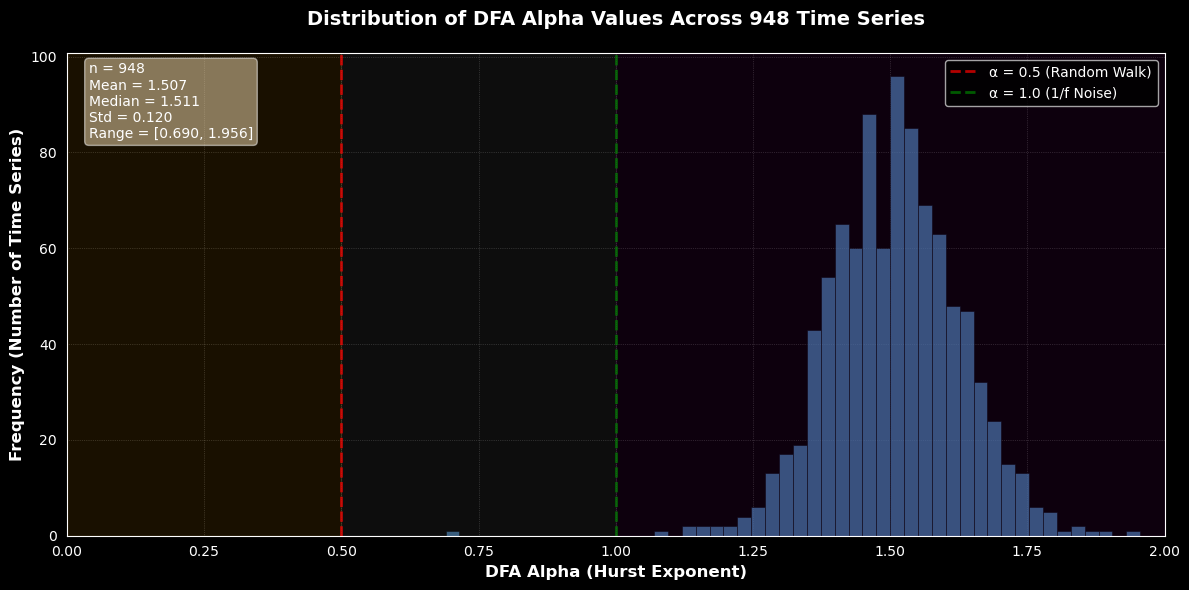

DISTRIBUTION ANALYSIS: 

Interpretation:
  Anti-persistent (α < 0.5): 0 (0.0%)
  Persistent (0.5 ≤ α < 1.0): 1 (0.1%)
  Strong trend (α ≥ 1.0): 947 (99.9%)


In [39]:
visualize_alpha_distribution(results_df, bins=50)

## Spectral Entropy

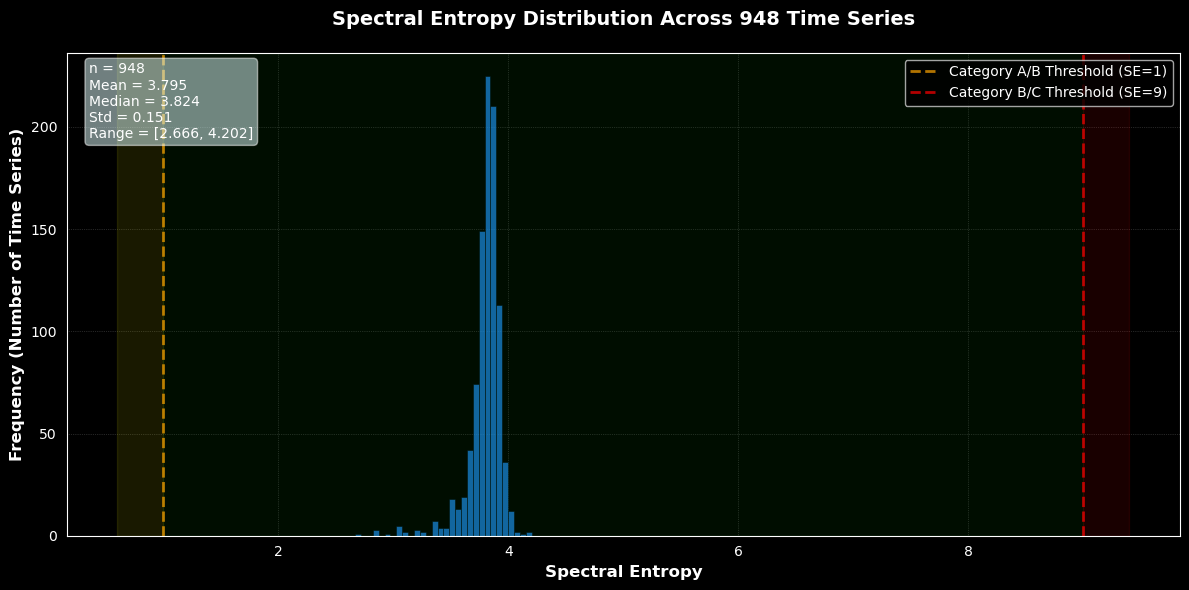


DISTRIBUTION ANALYSIS - SPECTRAL ENTROPY DIVERSITY
Empty intervals detected: 6 out of 30 bins
Bin width: 0.0512

Empty interval ranges:
  [2.7176, 2.7688]
  [2.7688, 2.8200]
  [2.8712, 2.9224]
  [2.9735, 3.0247]
  [3.1271, 3.1783]
  [3.2806, 3.3318]

Complexity Interpretation (Paper Categories):
  Category A (SE < 1): 0 (0.0%)
    → Low complexity, power concentrated in few frequencies
  Category B (1 ≤ SE < 9): 948 (100.0%)
    → Moderate complexity, typical financial behavior
  Category C (9 ≤ SE): 0 (0.0%)
    → High complexity, power spread across many frequencies


In [126]:
visualize_spectral_entropy_distribution(spectral_entropy_results, bins=30)

## Normality

### Kurtosis

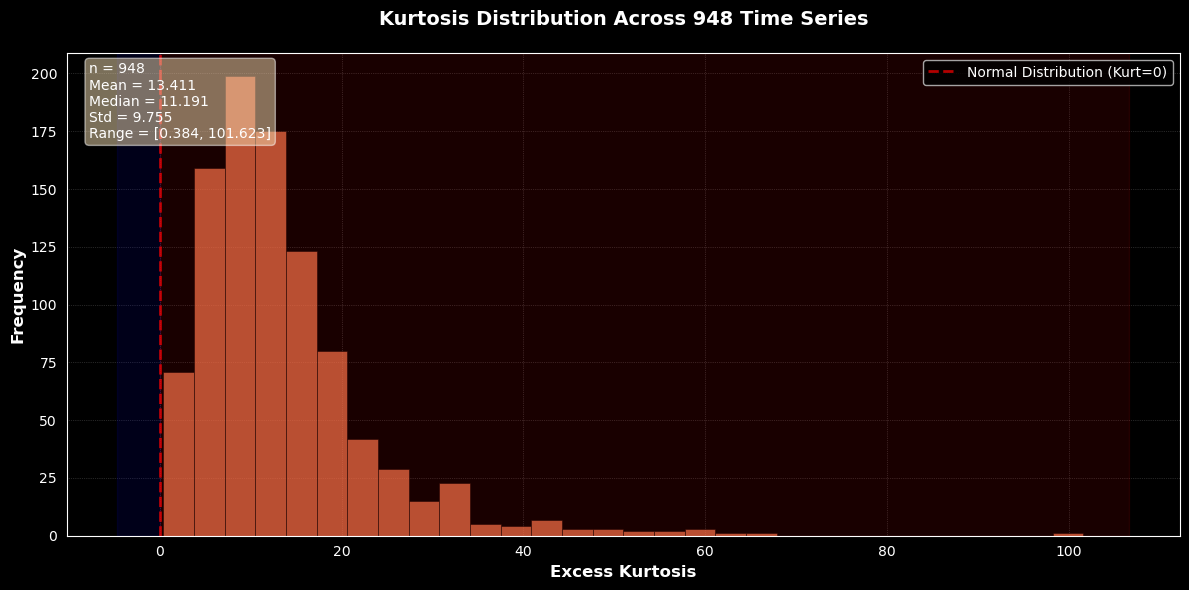

In [98]:
visualize_kurtosis_distribution(normality_results, bins=30)

### Skewness

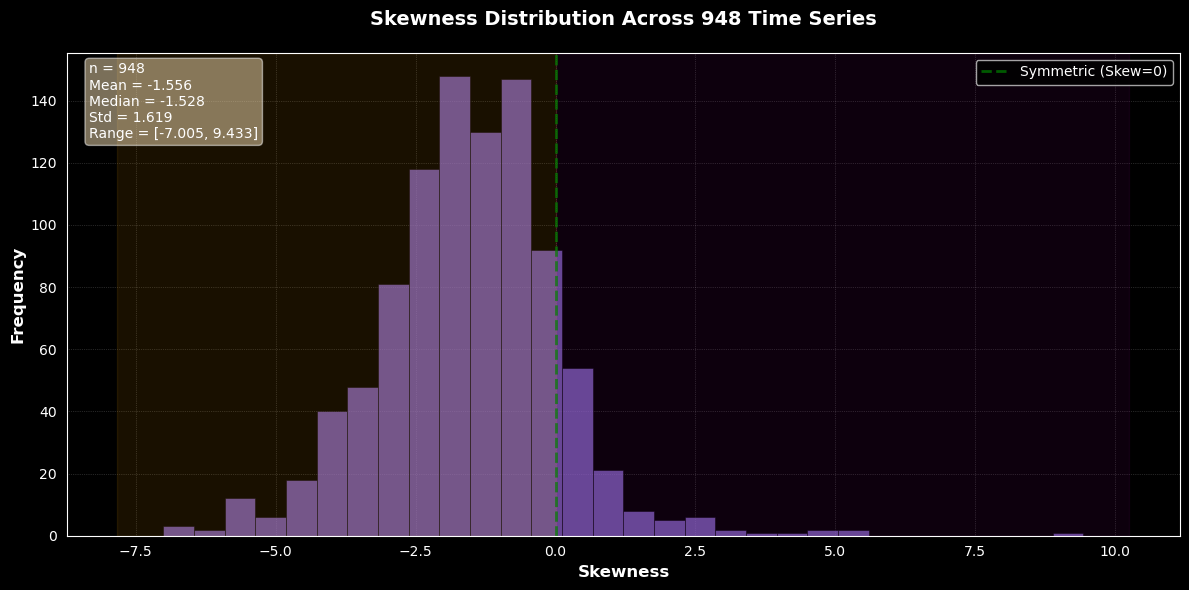

In [99]:
visualize_skewness_distribution(normality_results, bins=30)

### Gaussianity of Difference: Jarque-Bera test statistic

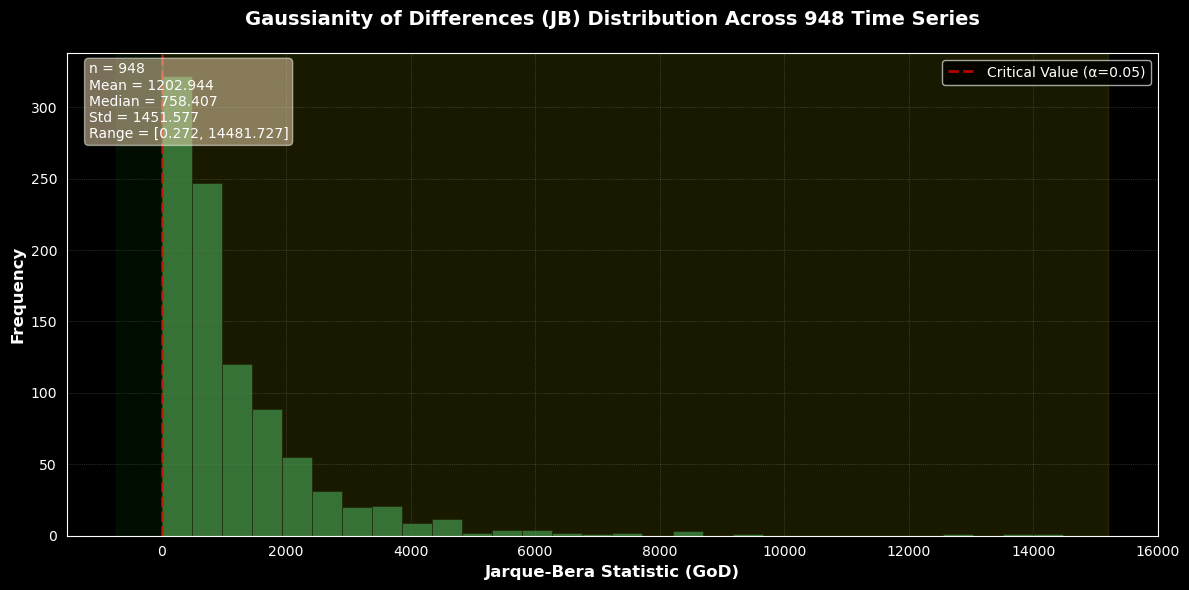

In [100]:
visualize_god_distribution(normality_results, bins=30)

# Multivariate entropy score

In [130]:
def print_diversity_report(diversity_score, table1, table2):
    """
    Print a comprehensive diversity report with both tables and final score.
    """
    print("\n" + "="*80)
    print("MULTIVARIATE ENTROPY DIVERSITY SCORE REPORT")
    print("="*80)

    print("\nTABLE 1: Proportion of Dataset Relative to Time Series Characteristic")
    print("-" * 80)
    # Format table1 with better display
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    print(table1.to_string(index=False, float_format=lambda x: f'{x:.3f}' if pd.notna(x) else 'N/A'))

    print("\n\nTABLE 2: Entropy Scores for Each Metric")
    print("-" * 80)
    print(table2.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

    print("\n" + "="*80)
    print(f"FINAL DIVERSITY SCORE: {diversity_score:.4f}")
    print("="*80)

    # Interpretation
    print("\nInterpretation:")
    if diversity_score >= 0.9:
        print("  → EXCELLENT diversity (0.9-1.0): Dataset covers feature space very evenly")
    elif diversity_score >= 0.75:
        print("  → GOOD diversity (0.75-0.9): Dataset has good coverage with minor gaps")
    elif diversity_score >= 0.6:
        print("  → MODERATE diversity (0.6-0.75): Dataset has reasonable coverage but noticeable gaps")
    elif diversity_score >= 0.4:
        print("  → LOW diversity (0.4-0.6): Dataset has significant gaps in coverage")
    else:
        print("  → VERY LOW diversity (0-0.4): Dataset is highly concentrated in few categories")

    print("\nNote: A perfectly diverse dataset would have a score of 1.0, meaning")
    print("      all categories within each feature have equal proportions (perfect evenness).")
    print("="*80)

In [131]:
diversity_score, table1, table2 = calculate_diversity_score(
     dfa_results_df,                    # DFA results
     spectral_entropy_results,      # Spectral Entropy results
     normality_results              # Kurtosis, Skewness, GoD results
 )

print_diversity_report(diversity_score, table1, table2)

Total time series with all features: 952

MULTIVARIATE ENTROPY DIVERSITY SCORE REPORT

TABLE 1: Proportion of Dataset Relative to Time Series Characteristic
--------------------------------------------------------------------------------
         Feature     A     B     C   D     E     F     G
             DFA   NaN   NaN 0.001 NaN 0.307 0.342 0.346
Spectral Entropy   NaN 0.996   NaN NaN   NaN   NaN   NaN
        Kurtosis   NaN   NaN 0.996 NaN   NaN   NaN   NaN
        Skewness 0.816 0.098 0.082 NaN   NaN   NaN   NaN
             GoD   NaN 0.996   NaN NaN   NaN   NaN   NaN


TABLE 2: Entropy Scores for Each Metric
--------------------------------------------------------------------------------
         Feature   H(X)   Hmax     HE
             DFA 1.1269 1.9459 0.5791
Spectral Entropy 0.0272 1.0986 0.0247
        Kurtosis 0.0272 1.0986 0.0247
        Skewness 0.6210 1.0986 0.5652
             GoD 0.0272 0.6931 0.0392

FINAL DIVERSITY SCORE: 0.2466

Interpretation:
  → VERY LOW diversit